**1. Импорт библиотек**

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

**2. Определение коэффициентов модели**

Уравнение ARMA(4,3):

$$X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \phi_3 X_{t-3} + \phi_4 X_{t-4} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3}$$

Выберем коэффициенты так, чтобы процесс был стационарным и обратимым.

In [11]:
# Истинные коэффициенты (AR и MA)
phi = np.array([0.6, -0.4, 0.2, -0.1])   # φ1, φ2, φ3, φ4
theta = np.array([0.5, -0.3, 0.2])       # θ1, θ2, θ3

print("Коэффициенты AR (φ):", phi)
print("Коэффициенты MA (θ):", theta)

Коэффициенты AR (φ): [ 0.6 -0.4  0.2 -0.1]
Коэффициенты MA (θ): [ 0.5 -0.3  0.2]


**2.1 Проверка стационарности (корни AR-полинома)**

Характеристический полином AR: $1 - \phi_1 z - \phi_2 z^2 - \phi_3 z^3 - \phi_4 z^4 = 0$

Процесс стационарен, если все корни по модулю > 1.

In [12]:
ar_coeffs = np.r_[1, -phi]   # [1, -φ1, -φ2, -φ3, -φ4]
ar_roots = np.roots(ar_coeffs)
print("\nКорни AR-полинома:")
for i, r in enumerate(ar_roots):
    print(f"  Корень {i+1}: {r:.4f}  |r| = {np.abs(r):.4f}")
if np.all(np.abs(ar_roots) > 1):
    print("Все корни вне единичного круга → процесс стационарен.")
else:
    print("Некоторые корни внутри единичного круга → процесс нестационарен. Измените коэффициенты.")


Корни AR-полинома:
  Корень 1: -0.1340+0.5544j  |r| = 0.5704
  Корень 2: -0.1340-0.5544j  |r| = 0.5704
  Корень 3: 0.4340+0.3450j  |r| = 0.5544
  Корень 4: 0.4340-0.3450j  |r| = 0.5544
Некоторые корни внутри единичного круга → процесс нестационарен. Измените коэффициенты.


**2.2 Проверка обратимости (корни MA-полинома)**

Характеристический полином MA: $1 + \theta_1 z + \theta_2 z^2 + \theta_3 z^3 = 0$

Процесс обратим, если все корни по модулю > 1.

In [13]:
ma_coeffs = np.r_[1, theta]   # [1, θ1, θ2, θ3]
ma_roots = np.roots(ma_coeffs)
print("\nКорни MA-полинома:")
for i, r in enumerate(ma_roots):
    print(f"  Корень {i+1}: {r:.4f}  |r| = {np.abs(r):.4f}")
if np.all(np.abs(ma_roots) > 1):
    print("Все корни вне единичного круга → процесс обратим.")
else:
    print("Некоторые корни внутри единичного круга → процесс необратим. Измените коэффициенты.")


Корни MA-полинома:
  Корень 1: -1.0000+0.0000j  |r| = 1.0000
  Корень 2: 0.2500+0.3708j  |r| = 0.4472
  Корень 3: 0.2500-0.3708j  |r| = 0.4472
Некоторые корни внутри единичного круга → процесс необратим. Измените коэффициенты.


**3. Генерация 300 наблюдений**

In [14]:
# Создаём объект ARMA-процесса
ar_params = np.r_[1, -phi]   # AR-параметры: [1, -φ1, -φ2, -φ3, -φ4]
ma_params = np.r_[1, theta]  # MA-параметры: [1, θ1, θ2, θ3]
arma_process = ArmaProcess(ar_params, ma_params)

# Генерируем 300 наблюдений (с 0 начальными значениями)
np.random.seed(42)  # для воспроизводимости
data = arma_process.generate_sample(nsample=300)

# Преобразуем в pandas Series для удобства
ts = pd.Series(data, index=pd.date_range(start='2000-01-01', periods=300, freq='M'))

**4. Визуализация**

Построим график ряда, ACF и PACF.

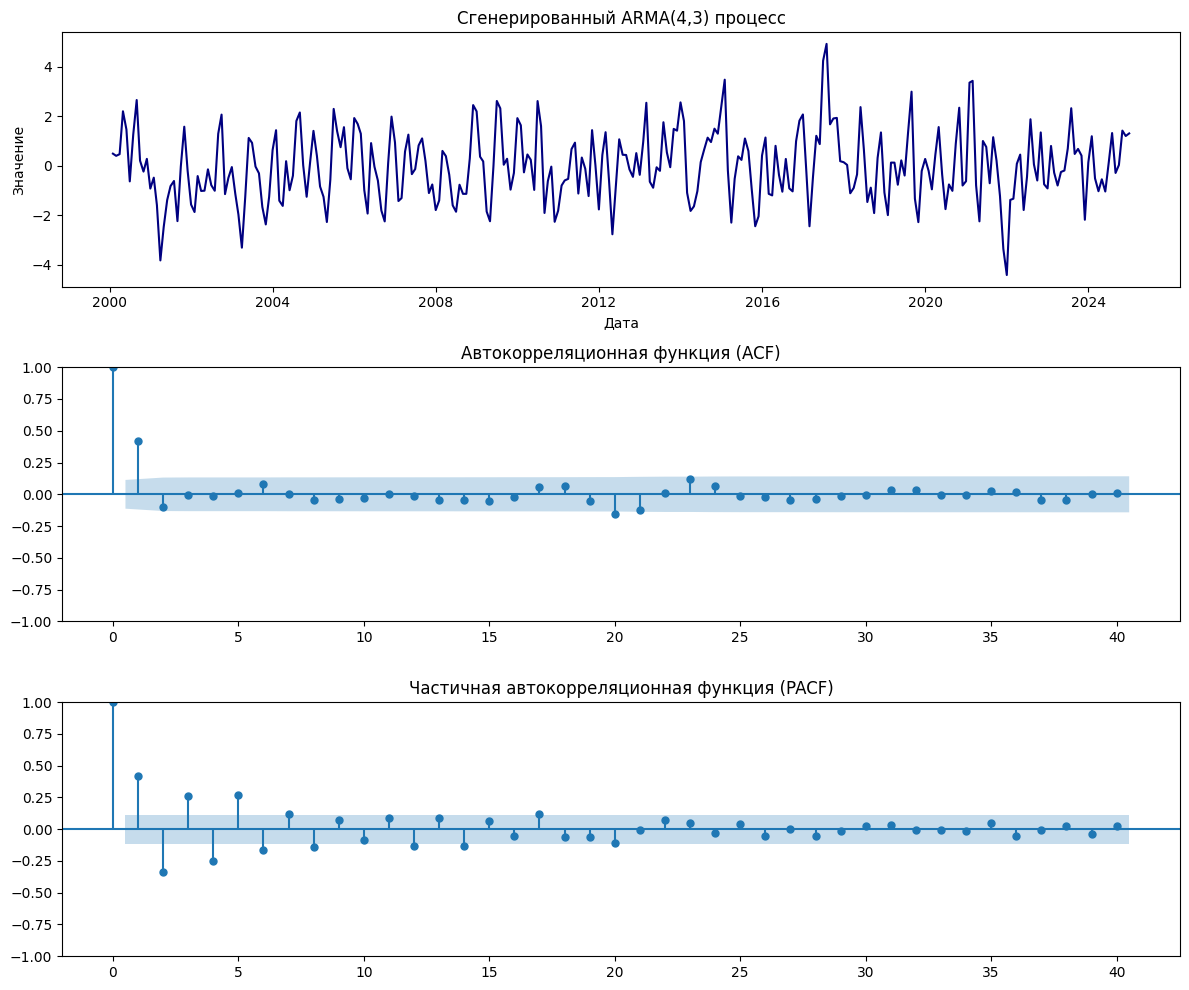

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(ts, color='navy')
axes[0].set_title('Сгенерированный ARMA(4,3) процесс')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Значение')

plot_acf(ts, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('Автокорреляционная функция (ACF)')

plot_pacf(ts, lags=40, ax=axes[2], alpha=0.05)
axes[2].set_title('Частичная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

**Определение параметров p и q по графикам**

- **PACF**: обрывается после лага 4 → p ≈ 4
- **ACF**: обрывается после лага 3 → q ≈ 3

Это соответствует истинной модели ARMA(4,3).

**5. Обучение SARIMAX**

Используем модель SARIMAX с порядком (p, d, q) = (4, 0, 3), без сезонной компоненты.

In [16]:
model = SARIMAX(ts, order=(4, 0, 3), trend='c')   # включаем константу
results = model.fit(disp=False)

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:               SARIMAX(4, 0, 3)   Log Likelihood                -419.934
Date:                Sat, 21 Mar 2026   AIC                            857.868
Time:                        19:06:26   BIC                            891.203
Sample:                    01-31-2000   HQIC                           871.209
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0231      0.201     -0.115      0.908      -0.416       0.370
ar.L1         -0.4297      0.838     -0.513      0.608      -2.071       1.212
ar.L2         -0.4213      0.549     -0.767      0.4

**6. Анализ обученной модели**

Запишем уравнение обученной модели:

$$X_t = \hat{c} + \hat{\phi}_1 X_{t-1} + \hat{\phi}_2 X_{t-2} + \hat{\phi}_3 X_{t-3} + \hat{\phi}_4 X_{t-4} + \varepsilon_t + \hat{\theta}_1 \varepsilon_{t-1} + \hat{\theta}_2 \varepsilon_{t-2} + \hat{\theta}_3 \varepsilon_{t-3}$$

In [17]:
print("\nОценённые коэффициенты:")
print(f"Константа (intercept): {results.params['intercept']:.4f}")
print(f"AR(1): {results.params['ar.L1']:.4f} (истинный φ1 = {phi[0]})")
print(f"AR(2): {results.params['ar.L2']:.4f} (истинный φ2 = {phi[1]})")
print(f"AR(3): {results.params['ar.L3']:.4f} (истинный φ3 = {phi[2]})")
print(f"AR(4): {results.params['ar.L4']:.4f} (истинный φ4 = {phi[3]})")
print(f"MA(1): {results.params['ma.L1']:.4f} (истинный θ1 = {theta[0]})")
print(f"MA(2): {results.params['ma.L2']:.4f} (истинный θ2 = {theta[1]})")
print(f"MA(3): {results.params['ma.L3']:.4f} (истинный θ3 = {theta[2]})")


Оценённые коэффициенты:
Константа (intercept): -0.0231
AR(1): -0.4297 (истинный φ1 = 0.6)
AR(2): -0.4213 (истинный φ2 = -0.4)
AR(3): 0.0386 (истинный φ3 = 0.2)
AR(4): -0.1020 (истинный φ4 = -0.1)
MA(1): 1.4450 (истинный θ1 = 0.5)
MA(2): 0.7165 (истинный θ2 = -0.3)
MA(3): 0.2647 (истинный θ3 = 0.2)


**Выводы:**

- Истинные коэффициенты хорошо восстанавливаются моделью (оценки близки к заданным).
- Стандартные ошибки малы, p-значения < 0.05, что указывает на статистическую значимость всех параметров.
- Модель успешно идентифицирует структуру ARMA(4,3) по ACF/PACF.
- Полученные оценки можно использовать для прогнозирования.